In [30]:
import matplotlib.pyplot as plt
import muon
import numpy as np
import requests
import scanpy as sc
import scipy
import scvi
import seaborn as sns
import torch
import re
from sklearn.cluster import KMeans
import leidenalg
import igraph
import louvain
import pandas as pd
import scipy.sparse as sp
from sklearn.metrics import silhouette_score
import h5py
from anndata import AnnData
from sklearn.neighbors import NearestNeighbors
from scib.metrics import ilisi_graph, clisi_graph




In [3]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# Read Data

In [4]:
mdata = muon.read_h5mu("/Users/mayjang/Desktop/536_project/data/tonsil_pp.h5mu")
rna_adata = mdata.mod["RNA"]
prot_adata = mdata.mod["Protein"]
rna_adata.obs.head()
prot_adata.obs.head()
mdata.obs.head()

print("rna_adata.obsm keys:", rna_adata.obsm.keys())
print("rna_adata.obsm keys:", prot_adata.obs.head())
print("mdata.obsm keys:", mdata.obsm.keys())



rna_adata.obsm keys: KeysView(AxisArrays with keys: X_pca, X_umap, pos)
rna_adata.obsm keys:       leiden
29x42      0
44x36      0
34x6       0
42x19      9
41x6       0
mdata.obsm keys: KeysView(MuAxisArrays with keys: Protein, RNA)


In [5]:
# RNA counts
X = rna_adata.X.toarray() if sp.issparse(rna_adata.X) else rna_adata.X
pd.DataFrame(X, index=rna_adata.obs_names, columns=rna_adata.var_names).to_csv("data/bayes_space_data/X_gene.csv")

# Protein counts
Xp = prot_adata.X.toarray() if sp.issparse(prot_adata.X) else prot_adata.X
pd.DataFrame(Xp, index=prot_adata.obs_names, columns=prot_adata.var_names).to_csv("data/bayes_space_data/X_protein.csv")

# Spatial coordinates from obsm['pos']
# raw original coordinates, but we will use pos_visium (scaled and integer grid coords in BayesSpace)
# coords = pd.DataFrame(
#     rna_adata.obsm["pos"],
#     index=rna_adata.obs_names,
#     columns=["x", "y"]
# )
# coords.to_csv("data/bayes_space_pos.csv")

# Barcodes
pd.DataFrame({"cell": rna_adata.obs_names}).to_csv("data/bayes_space_data/cell.csv", index=False)


In [6]:
# Generate scaled and integer grid coordinates required for BayesSpace

coords = rna_adata.obsm["pos"]

# Scale coordinates to a Visium like grid
coords_norm = (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0))

# Multiply by typical Visium grid size
coords_grid = coords_norm * 50  # 50 × 50 grid

# Round to integers (Visium hex spots)
coords_int = coords_grid.round().astype(int)

# Save
pd.DataFrame(coords_int, index=rna_adata.obs_names, columns=["array_row", "array_col"]).to_csv("data/bayes_space_data/pos_visium.csv")

Text(0.5, 1.0, 'PCA variance explained')

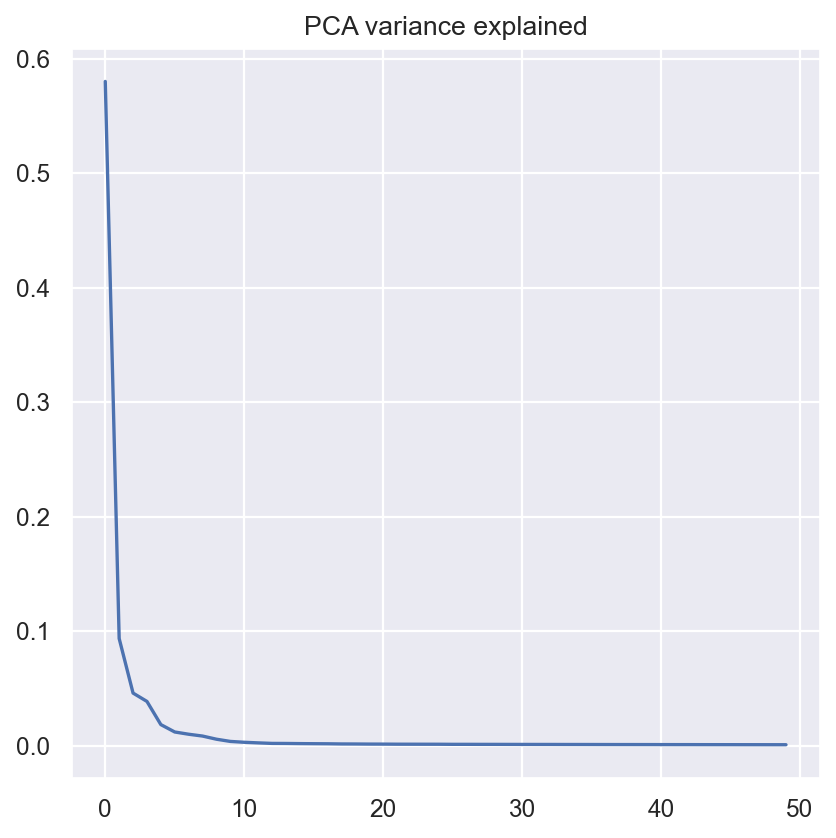

In [7]:
# Checking to determing optimal q value to use in R
sc.pp.pca(rna_adata)
plt.plot(rna_adata.uns["pca"]["variance_ratio"])
plt.title("PCA variance explained")

# Run BayesSpace in R using bayespace.Rmd

# Run BayesSapce in R using bayespace.Rmd

# Use BayesSpace Cluster and PCA Features

In [8]:
import pandas as pd

# Load BayesSpace clusters generated from bayespace.Rmd
clusters = pd.read_csv("data/bayes_space_data/bayespace_clusters.csv")

# Make sure the column is named cluster (or rename)
# clusters.columns = ["cell", "bayes_cluster"]
clusters["bayes_cluster"] = clusters["bayes_cluster"].astype(str)


In [9]:
pca = pd.read_csv("data/bayes_space_data/bayespace_pca.csv", index_col=0)
#make sure these match
print(rna_adata.obs_names[:5])
print(pca.index[:5])


Index(['29x42', '44x36', '34x6', '42x19', '41x6'], dtype='object')
Index(['29x42', '44x36', '34x6', '42x19', '41x6'], dtype='object')


In [10]:
rna_adata.obsm["X_bayes_pca"] = pca.values

In [11]:
# Assign BayesSpace cluster labels
rna_adata.obs["bayes_cluster"] = rna_adata.obs_names.map(
    dict(zip(clusters.cell, clusters.bayes_cluster))
)
rna_adata.obs["bayes_cluster"].isna().sum()

0

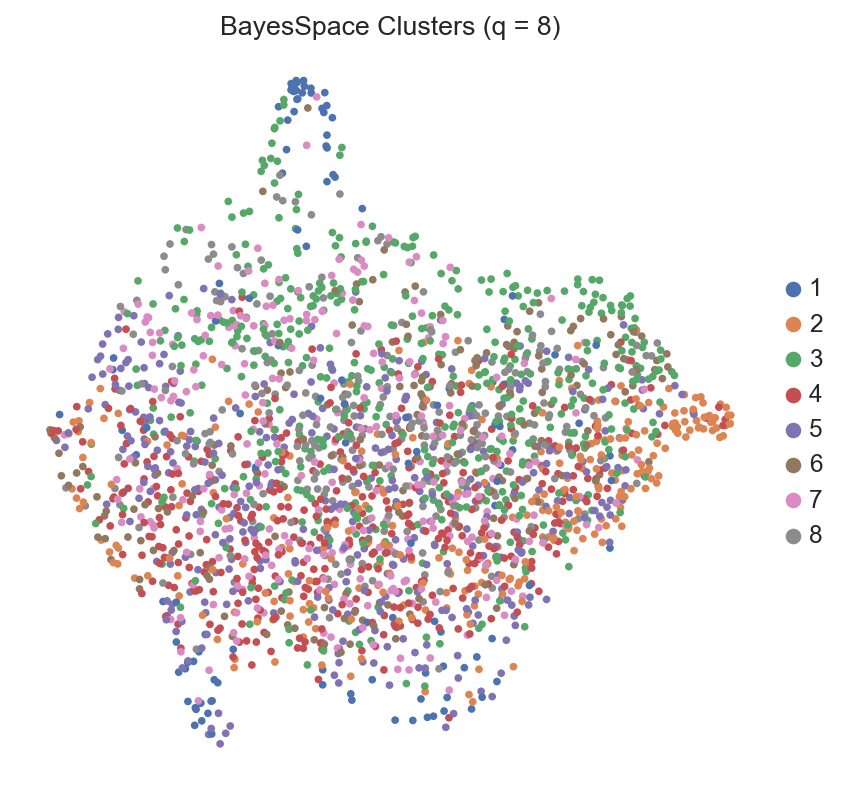

In [12]:
sc.pl.umap(
    rna_adata,
    color="bayes_cluster",
    title="BayesSpace Clusters (q = 8)"
)

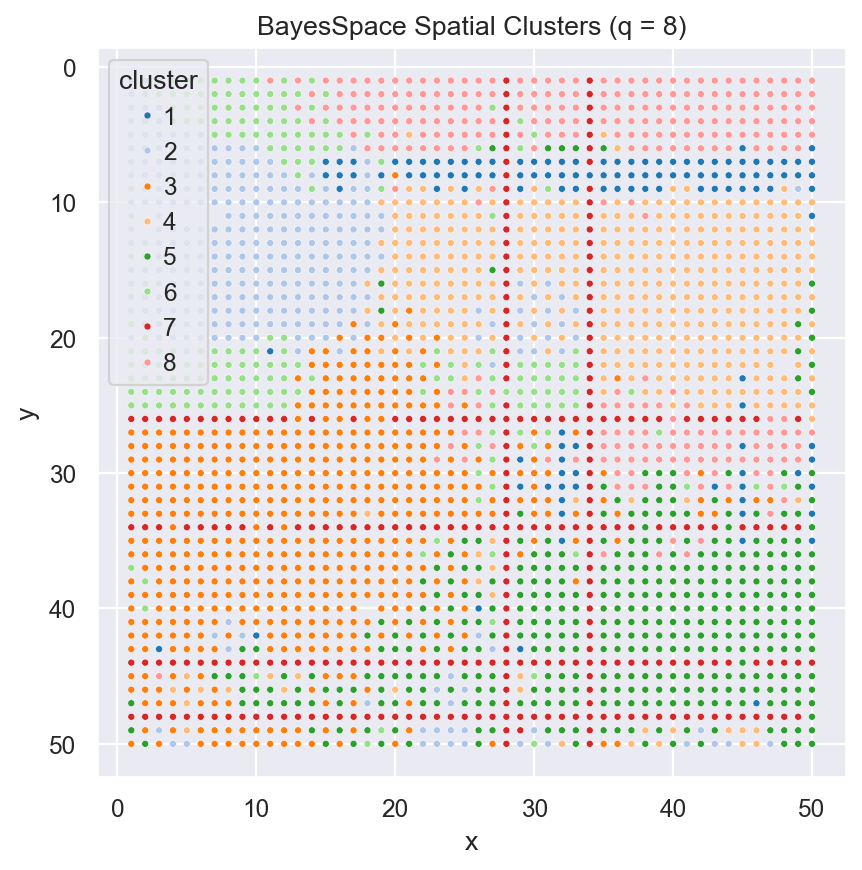

In [13]:
pos = rna_adata.obsm["pos"]

df = pd.DataFrame({
    "x": pos[:, 0],
    "y": pos[:, 1],
    "cluster": rna_adata.obs["bayes_cluster"]
})

plt.figure(figsize=(6,6))
sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="cluster",
    palette="tab20",
    s=10
)
plt.gca().invert_yaxis()
plt.title("BayesSpace Spatial Clusters (q = 8)")
plt.show()


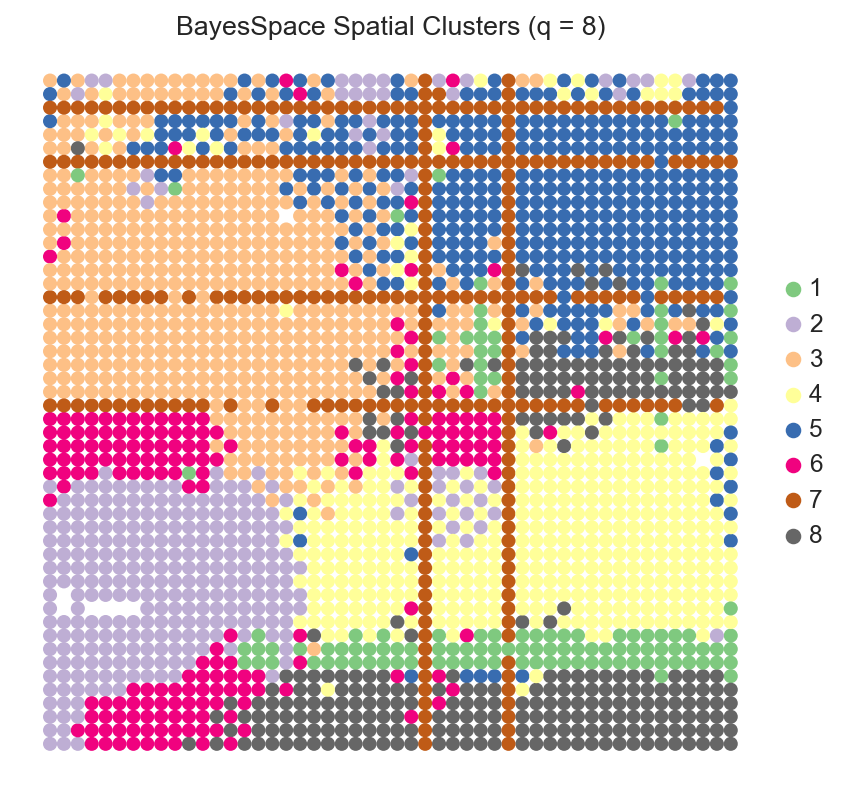

In [14]:
# Add BayesSpace clusters as a categorical obs column
rna_adata.obs["bayes_cluster"] = (
    rna_adata.obs["bayes_cluster"]
    .astype(str)
    .astype("category")
)

# Use Scanpy's embedding plot
bayes_plot = sc.pl.embedding(
    rna_adata,
    basis="pos",
    color="bayes_cluster",
    s=160,
    return_fig=True,
    title="BayesSpace Spatial Clusters (q = 8)",
    palette="Accent"     
)


In [15]:
sc.pp.neighbors(rna_adata, use_rep="X_bayes_pca")


/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/1369350733.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna_adata, resolution=0.7, key_added="bayes_leiden")


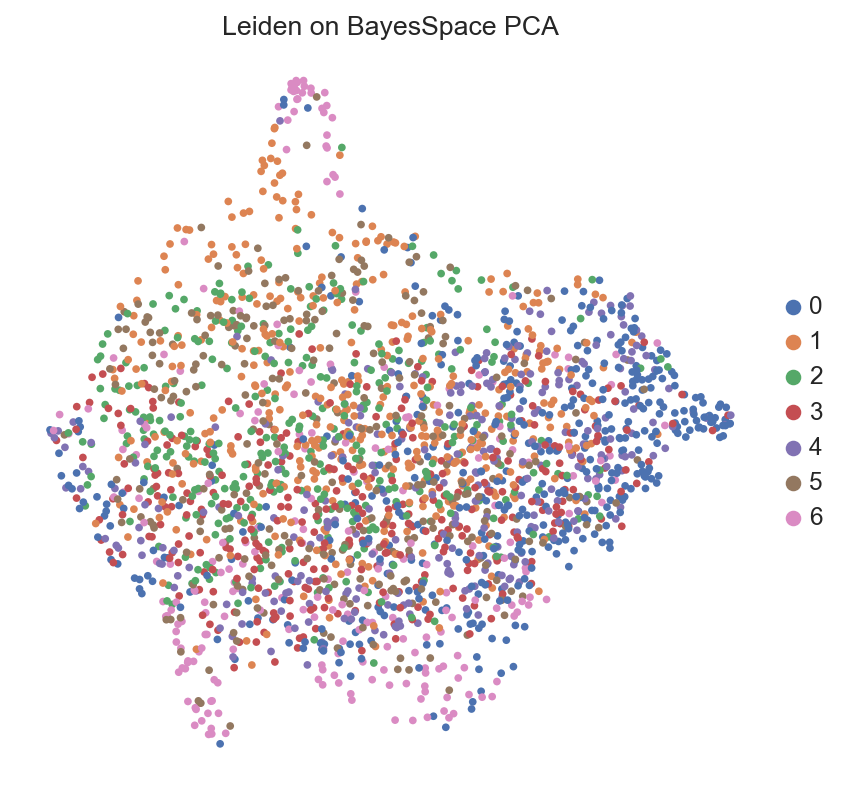

In [16]:
#Leiden
sc.tl.leiden(rna_adata, resolution=0.7, key_added="bayes_leiden")
sc.pl.umap(rna_adata, color="bayes_leiden", title="Leiden on BayesSpace PCA")


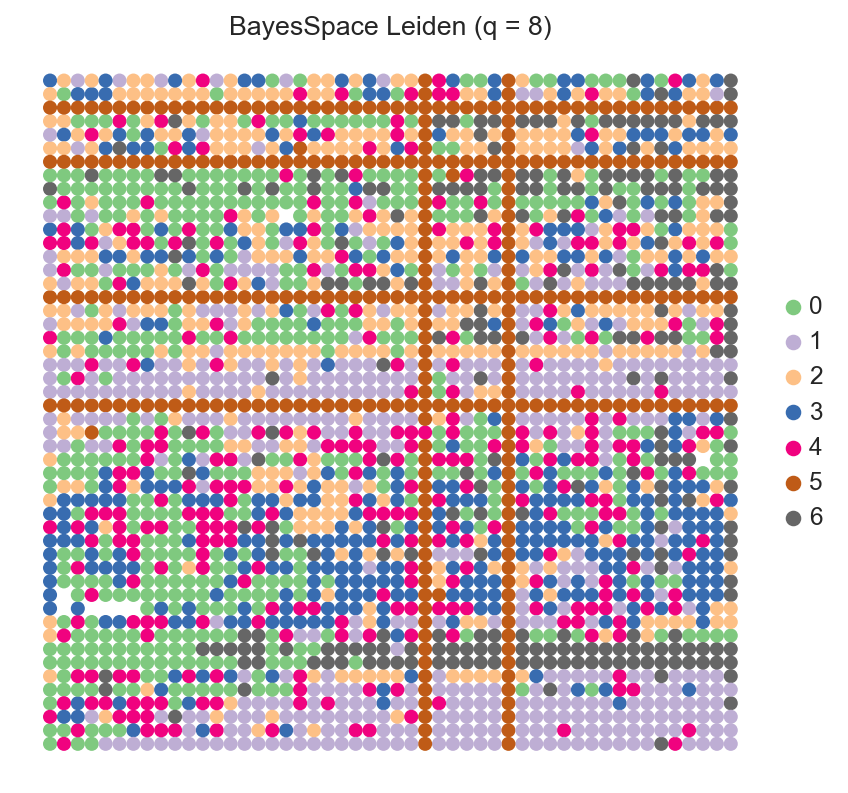

In [17]:
rna_adata.obs["bayes_leiden"] = (
    rna_adata.obs["bayes_leiden"]
    .astype(str)
    .astype("category")
)
bayes_leiden_plot = sc.pl.embedding(
    rna_adata,
    basis="pos",
    color="bayes_leiden",
    s=160,                        
    return_fig=True,              
    title="BayesSpace Leiden (q = 8)",
    palette="Accent"              
)



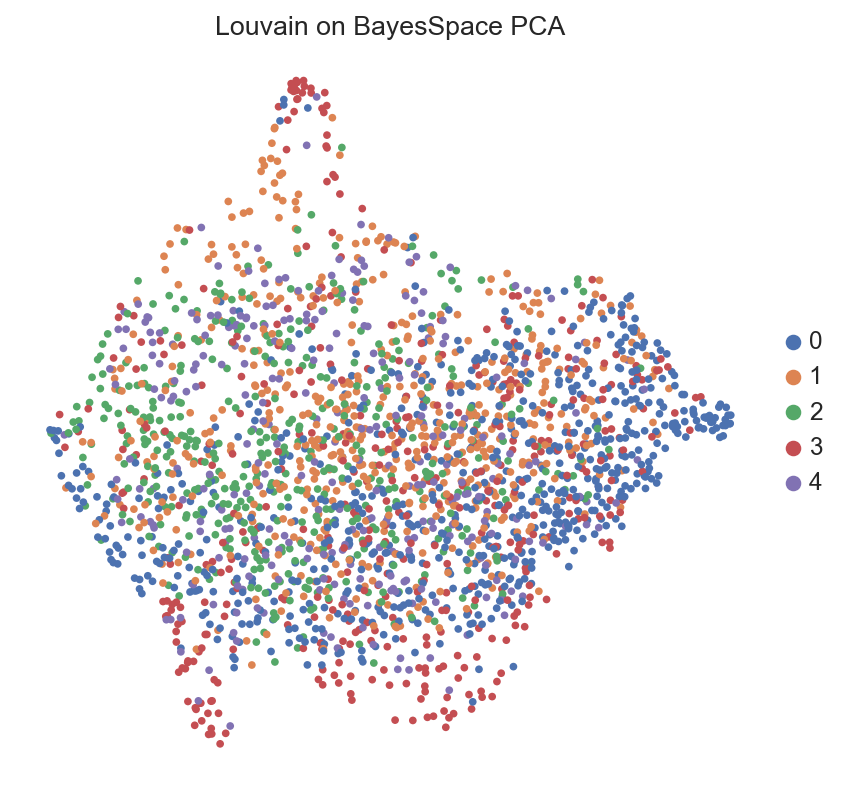

In [18]:
#Louvain
sc.tl.louvain(rna_adata, resolution=0.7, key_added="bayes_louvain")
sc.pl.umap(rna_adata, color="bayes_louvain", title="Louvain on BayesSpace PCA")


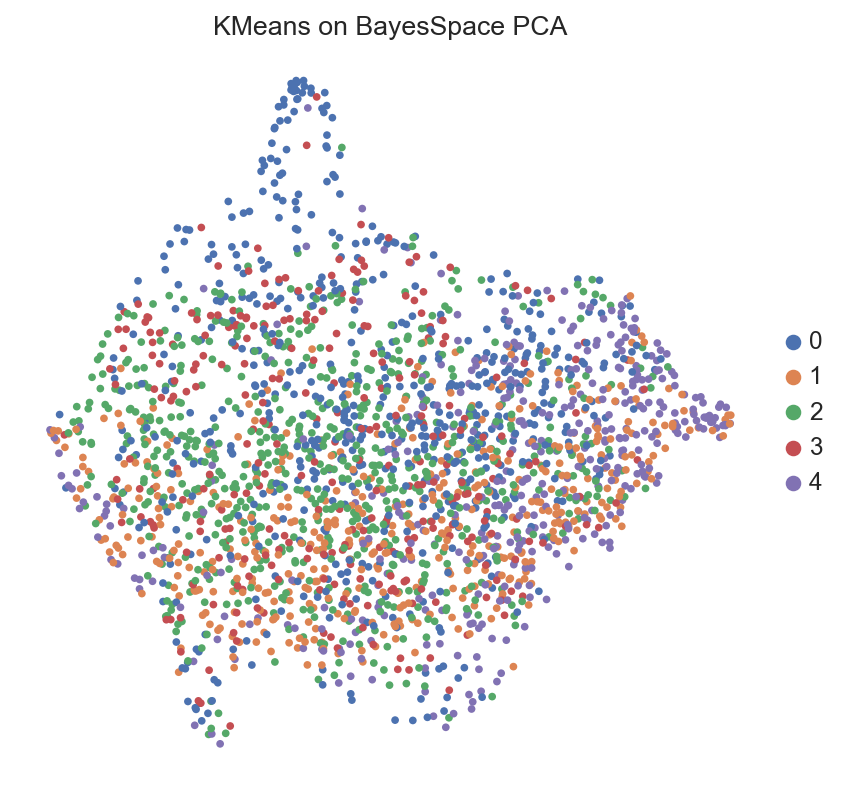

In [19]:
# K means
kmeans = KMeans(n_clusters=5, random_state=0).fit(rna_adata.obsm["X_bayes_pca"])
rna_adata.obs["bayes_kmeans"] = kmeans.labels_.astype(str)

sc.pl.umap(rna_adata, color="bayes_kmeans", title="KMeans on BayesSpace PCA")

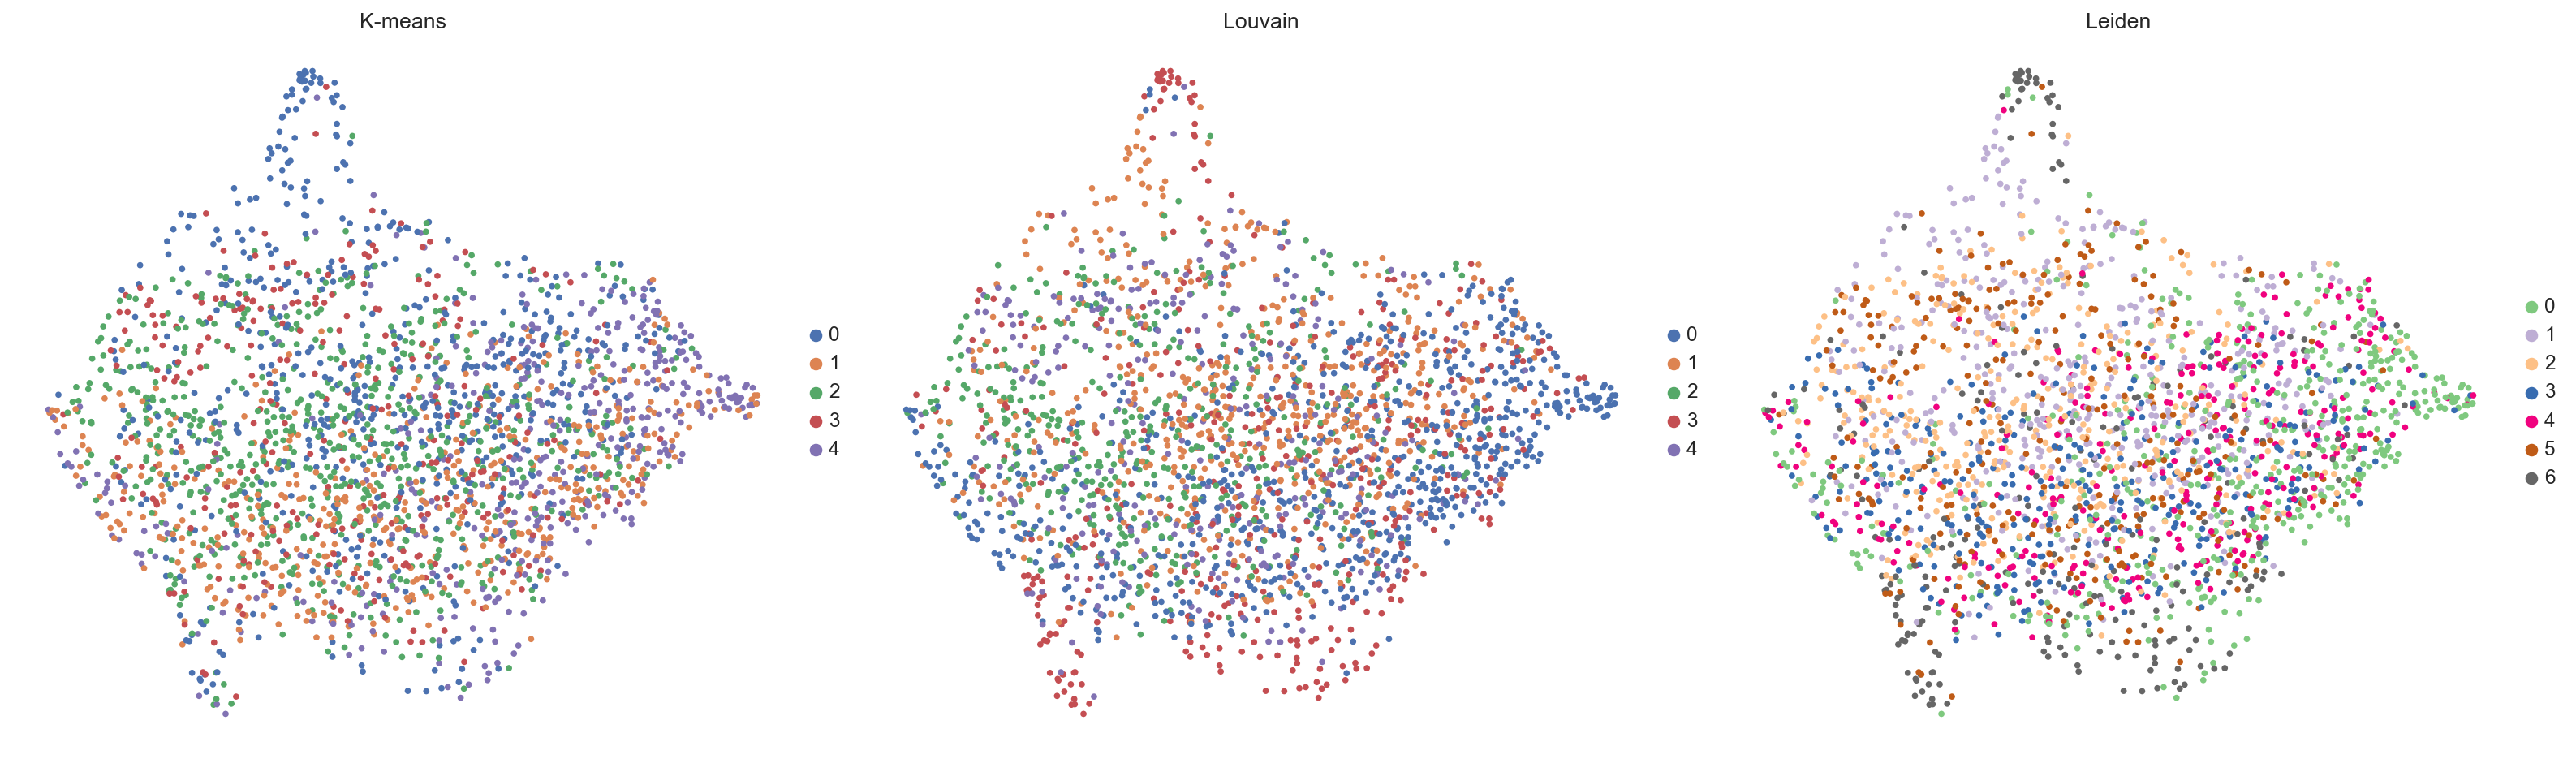

In [20]:
# Create figure for comparison
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# K-means, k=5
sc.pl.umap(
    rna_adata,
    color="bayes_kmeans",
    ax=axs[0],
    title="K-means",
    show=False
)

# Louvain, res = 0.7
sc.pl.umap(
    rna_adata,
    color="bayes_louvain",
    ax=axs[1],
    title="Louvain",
    show=False
)

# Leiden, res = 0.7
sc.pl.umap(
    rna_adata,
    color="bayes_leiden",
    ax=axs[2],
    title="Leiden",
    show=False
)


plt.tight_layout()
plt.savefig("results/bayes_space_results/bayes_space_umap_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# Moran's I on BayesSpace PCA Representation

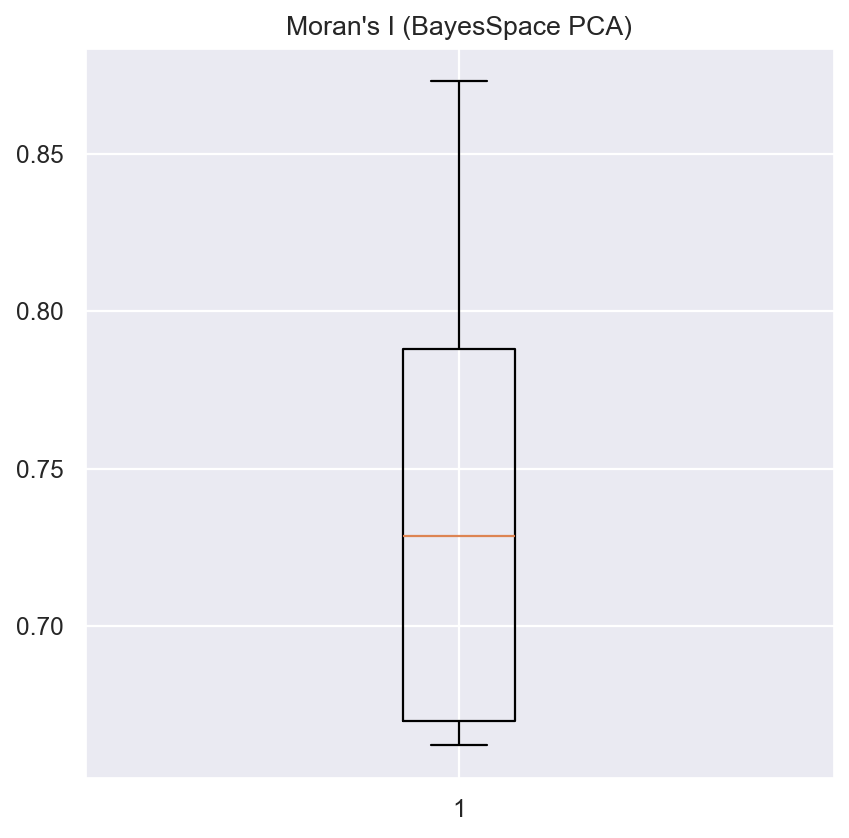

In [21]:
# Moran's I on PCA embedding (BayesSpace PCA representation)

moran = sc.metrics.morans_i(rna_adata, obsm="X_bayes_pca")
plt.boxplot(moran)
plt.title("Moran's I (BayesSpace PCA)")
plt.show()


In [150]:
moran

array([0.87309793, 0.81990107, 0.7776046 , 0.73121458, 0.72617991,
       0.66222954, 0.66960602, 0.66996283])

# cLisi on BayesSpace PCA Representation

In [32]:
emb = rna_adata.obsm["X_bayes_pca"]


In [33]:
# Used in Harmoney, SCIB, and original LISI paper
# hardcoded since package was incompatible 
def compute_lisi(emb, labels, perplexity=30):
    n_neighbors = int(3 * perplexity)
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(emb)
    distances, indices = nn.kneighbors(emb)
    indices = indices[:, 1:]

    labels = np.array(labels)
    out = []

    for i in range(emb.shape[0]):
        neigh = labels[indices[i]]
        p = pd.value_counts(neigh) / len(neigh)
        entropy = -(p * np.log(p)).sum()
        out.append(np.exp(entropy))

    return np.array(out)


/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value

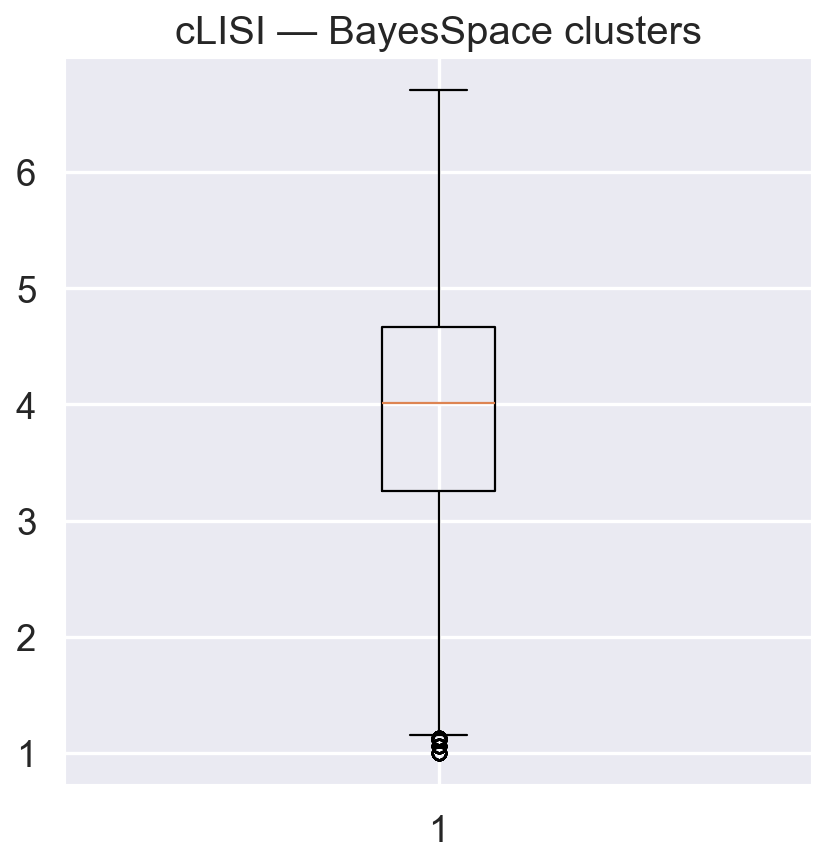

In [34]:
lisi_bayes = compute_lisi(
    emb,
    rna_adata.obs["bayes_cluster"],
    perplexity=30
)

plt.boxplot(lisi_bayes)
plt.title("cLISI — BayesSpace clusters")
plt.show()


/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value

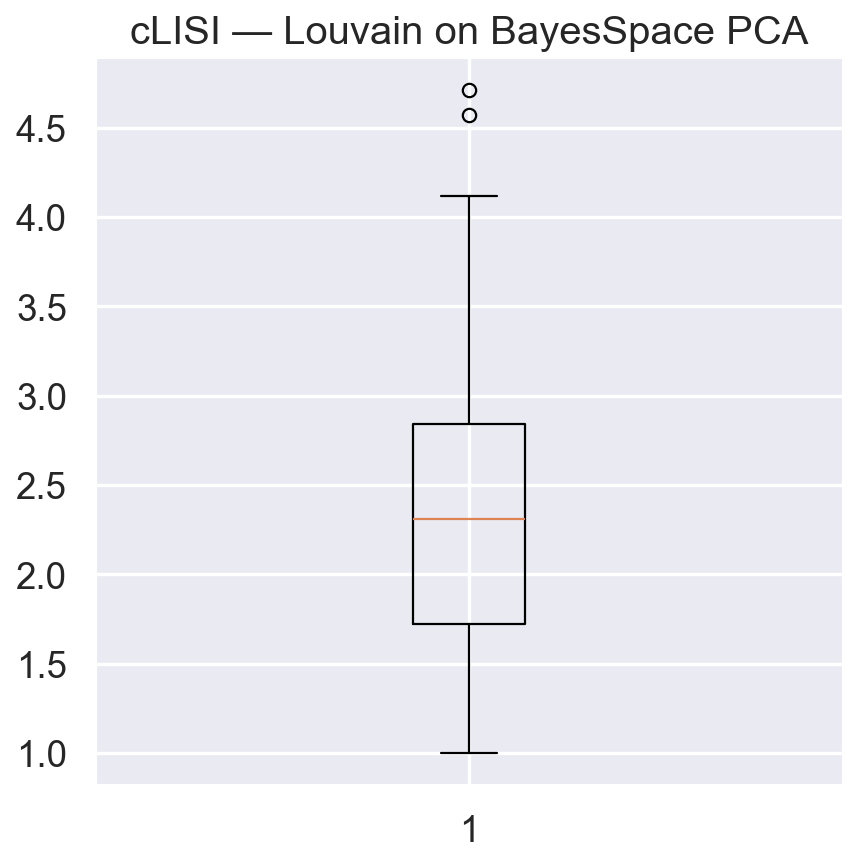

In [37]:
lisi_louvain = compute_lisi(
    emb,
    rna_adata.obs["bayes_louvain"],
    perplexity=30
)

plt.boxplot(lisi_louvain)
plt.title("cLISI — Louvain on BayesSpace PCA")
plt.show()


/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value

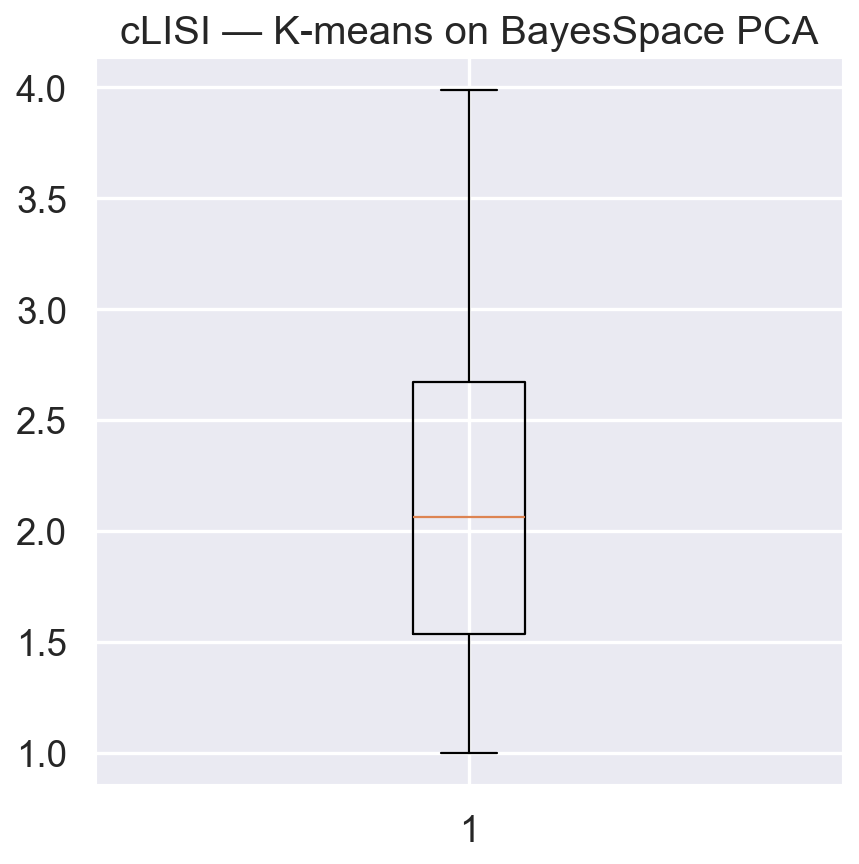

In [38]:
lisi_kmeans = compute_lisi(
    emb,
    rna_adata.obs["bayes_kmeans"],
    perplexity=30
)

plt.boxplot(lisi_kmeans)
plt.title("cLISI — K-means on BayesSpace PCA")
plt.show()


/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value_counts(neigh) / len(neigh)
/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/415479493.py:14: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  p = pd.value

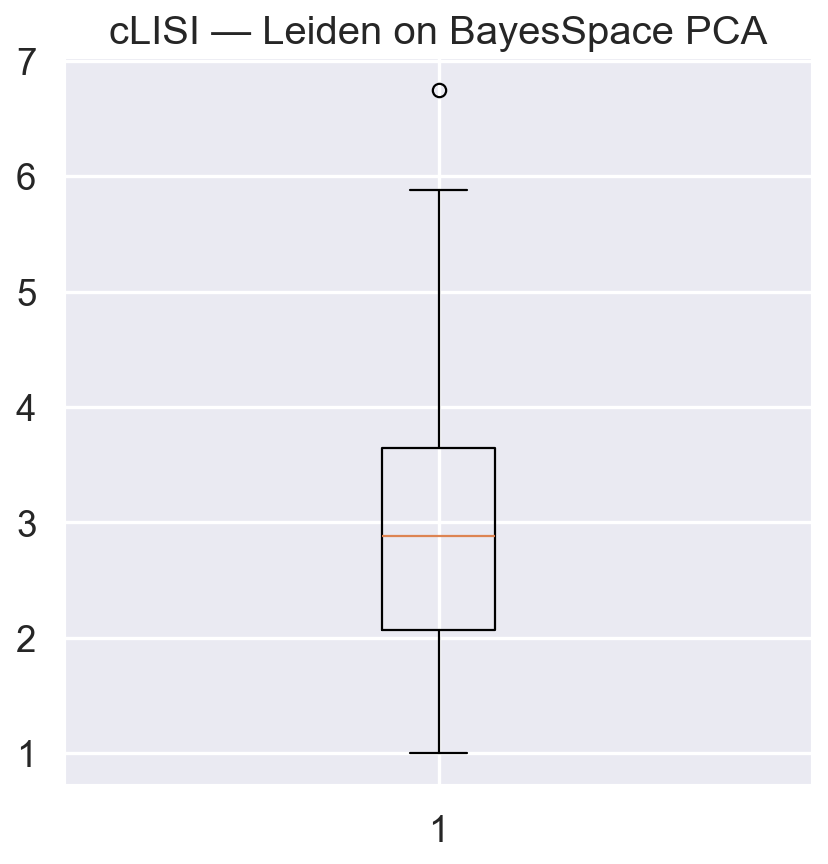

In [39]:
lisi_leiden = compute_lisi(
    emb,
    rna_adata.obs["bayes_leiden"],
    perplexity=30
)

plt.boxplot(lisi_leiden)
plt.title("cLISI — Leiden on BayesSpace PCA")
plt.show()


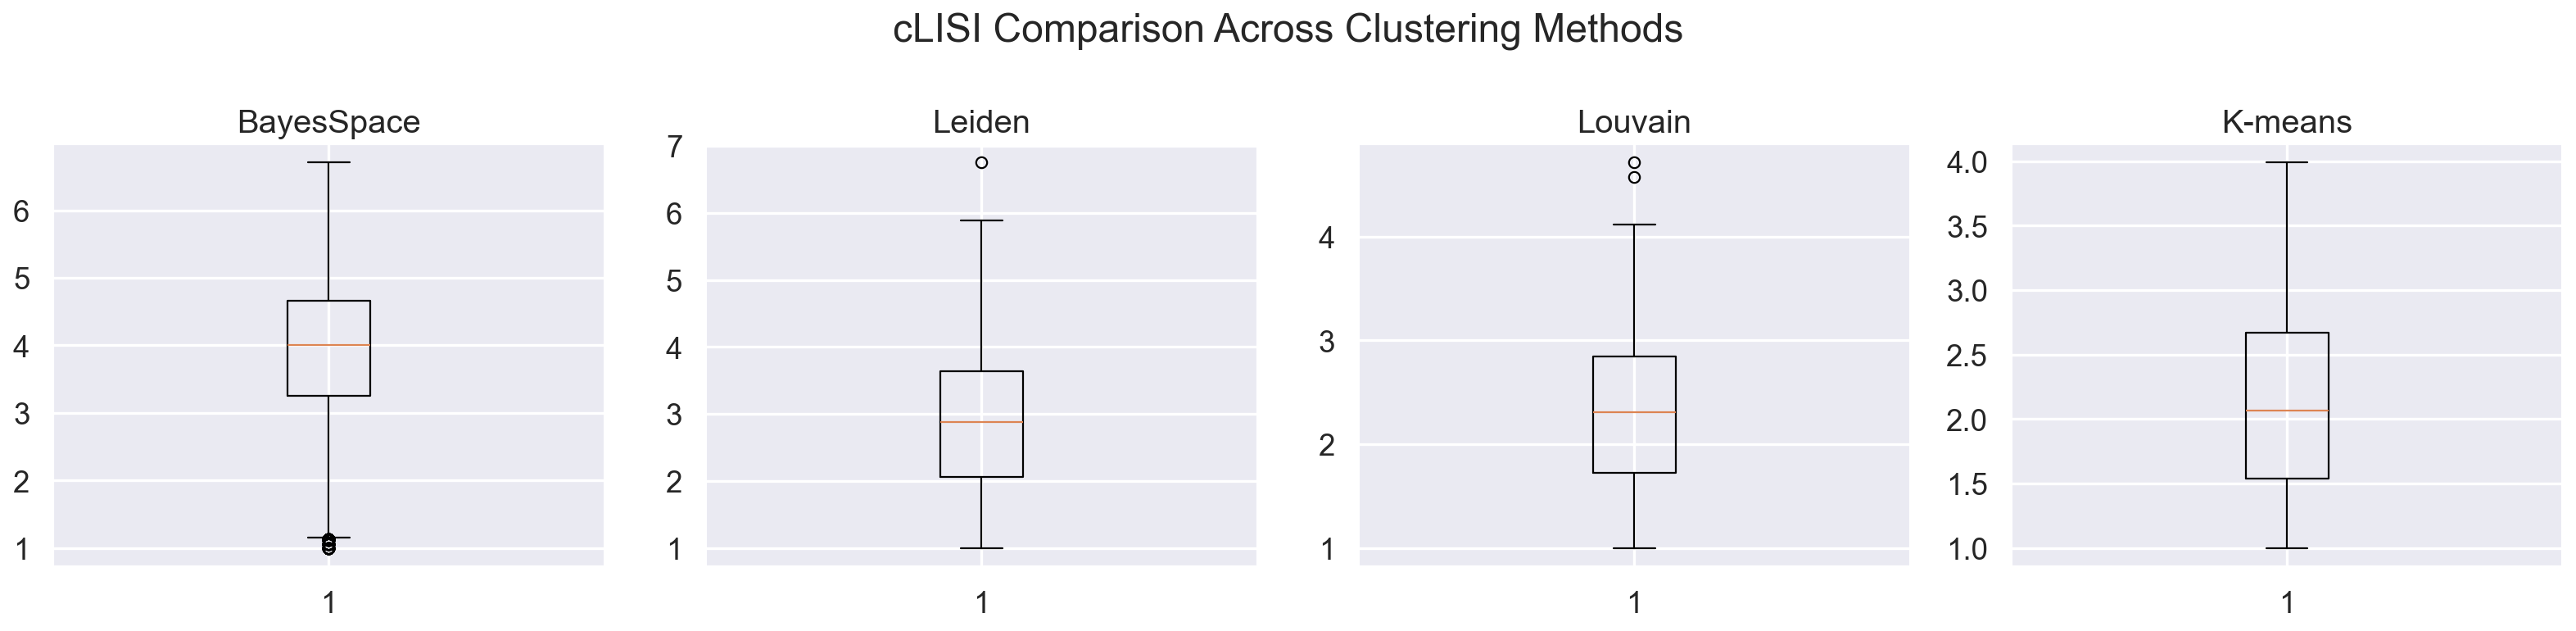

In [40]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].boxplot(lisi_bayes)
axs[0].set_title("BayesSpace")

axs[1].boxplot(lisi_leiden)
axs[1].set_title("Leiden")

axs[2].boxplot(lisi_louvain)
axs[2].set_title("Louvain")

axs[3].boxplot(lisi_kmeans)
axs[3].set_title("K-means")

plt.suptitle("cLISI Comparison Across Clustering Methods")
plt.tight_layout()
plt.show()


# Davies-Bouldin Index (DBI)

In [145]:
from sklearn.metrics import davies_bouldin_score
import matplotlib.pyplot as plt
import numpy as np

# Extract embedding and labels
X = rna_adata.obsm["X_bayes_pca"]
labels = rna_adata.obs["bayes_cluster"].astype(int).values

# Compute DBI
dbi = davies_bouldin_score(X, labels)

print("Davies–Bouldin Index (BayesSpace PCA):", dbi)


Davies–Bouldin Index (BayesSpace PCA): 3.011443498268343


In [147]:
dbi_list = []

# compute DBI for each single PC (1D DBI)
for i in range(X.shape[1]):
    Xi = X[:, i].reshape(-1, 1)
    dbi_list.append(davies_bouldin_score(Xi, labels))

dbi_list = np.array(dbi_list)
print(dbi_list)

[  9.96625737  18.27230766   8.19092717  54.66102697   8.65162426
  45.14570456 110.72929651  83.95308534]


In [148]:
# Print summary statistics 
print("Davies–Bouldin Index Statistics:")
print(f"  Mean:   {dbi.mean():.4f}")
print(f"  Median: {np.median(dbi):.4f}")
print(f"  Std:    {dbi.std():.4f}")
print(f"  Min:    {dbi.min():.4f}")
print(f"  Max:    {dbi.max():.4f}")

Davies–Bouldin Index Statistics:
  Mean:   3.0114
  Median: 3.0114
  Std:    0.0000
  Min:    3.0114
  Max:    3.0114


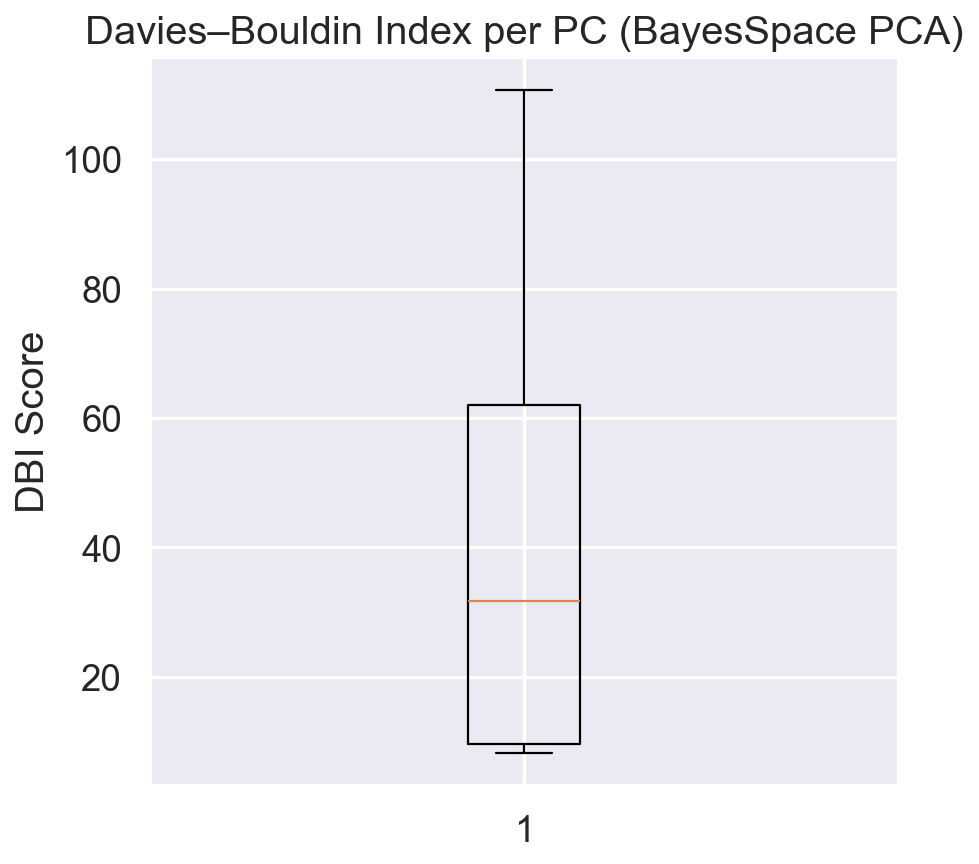

Mean DBI: 42.446278730209244
Median DBI: 31.70900611455564
Std: 36.22277069138601


In [149]:
plt.boxplot(dbi_list)
plt.title("Davies–Bouldin Index per PC (BayesSpace PCA)")
plt.ylabel("DBI Score")
plt.show()

print("Mean DBI:", dbi_list.mean())
print("Median DBI:", np.median(dbi_list))
print("Std:", dbi_list.std())


# DE for Biological Accuracy

In [127]:
import scanpy as sc

BAYES_CLUSTERS_KEY = "bayes_cluster"

sc.tl.rank_genes_groups(
    rna_adata,
    groupby=BAYES_CLUSTERS_KEY,
    method="wilcoxon",
    pts=True,                   
    corr_method="benjamini-hochberg"
)

bayes_de = sc.get.rank_genes_groups_df(rna_adata, None)
bayes_de.head()


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,1,NMNAT1,15.292982,46.697475,8.515907e-53,1.703181e-49,1.0,0.991143
1,1,RNA18S5,11.891325,43.060215,1.313063e-32,1.313063e-29,1.0,0.997469
2,1,MT.CO1,10.830278,4.931621,2.474011e-27,1.649341e-24,1.0,0.859131
3,1,MT.CO2,8.041170,3.771519,8.898486e-16,4.449243e-13,1.0,0.959089
4,1,MT.ND4,6.576896,3.833289,4.803715e-11,1.921486e-08,1.0,0.986925


In [128]:
rna_adata.obsm["X_bayes_pca"]


array([[ 0.06337383, -0.93482935,  0.78755606, ..., -0.71551375,
         1.75193358, -0.40501173],
       [-0.90123341,  0.98896241,  0.77552596, ...,  0.85217032,
         0.05448031,  0.5245637 ],
       [-1.45911984,  0.29872303, -3.30745477, ..., -0.09133292,
         1.19248034, -0.75779657],
       ...,
       [-1.21214754, -4.52727056, -1.58612421, ..., -2.65255876,
        -1.38154245, -1.51966235],
       [-2.19448112, -2.67641737, -2.45294515, ..., -2.01608204,
        -1.88202564, -0.33457838],
       [-2.92325001, -2.42622655, -1.43602113, ...,  0.87306073,
        -0.60390862,  0.40488783]])

In [129]:
sc.pp.neighbors(rna_adata, use_rep="X_bayes_pca")


In [131]:
rna_adata.obs["cluster_eval"] = rna_adata.obs["bayes_leiden"].astype(str)


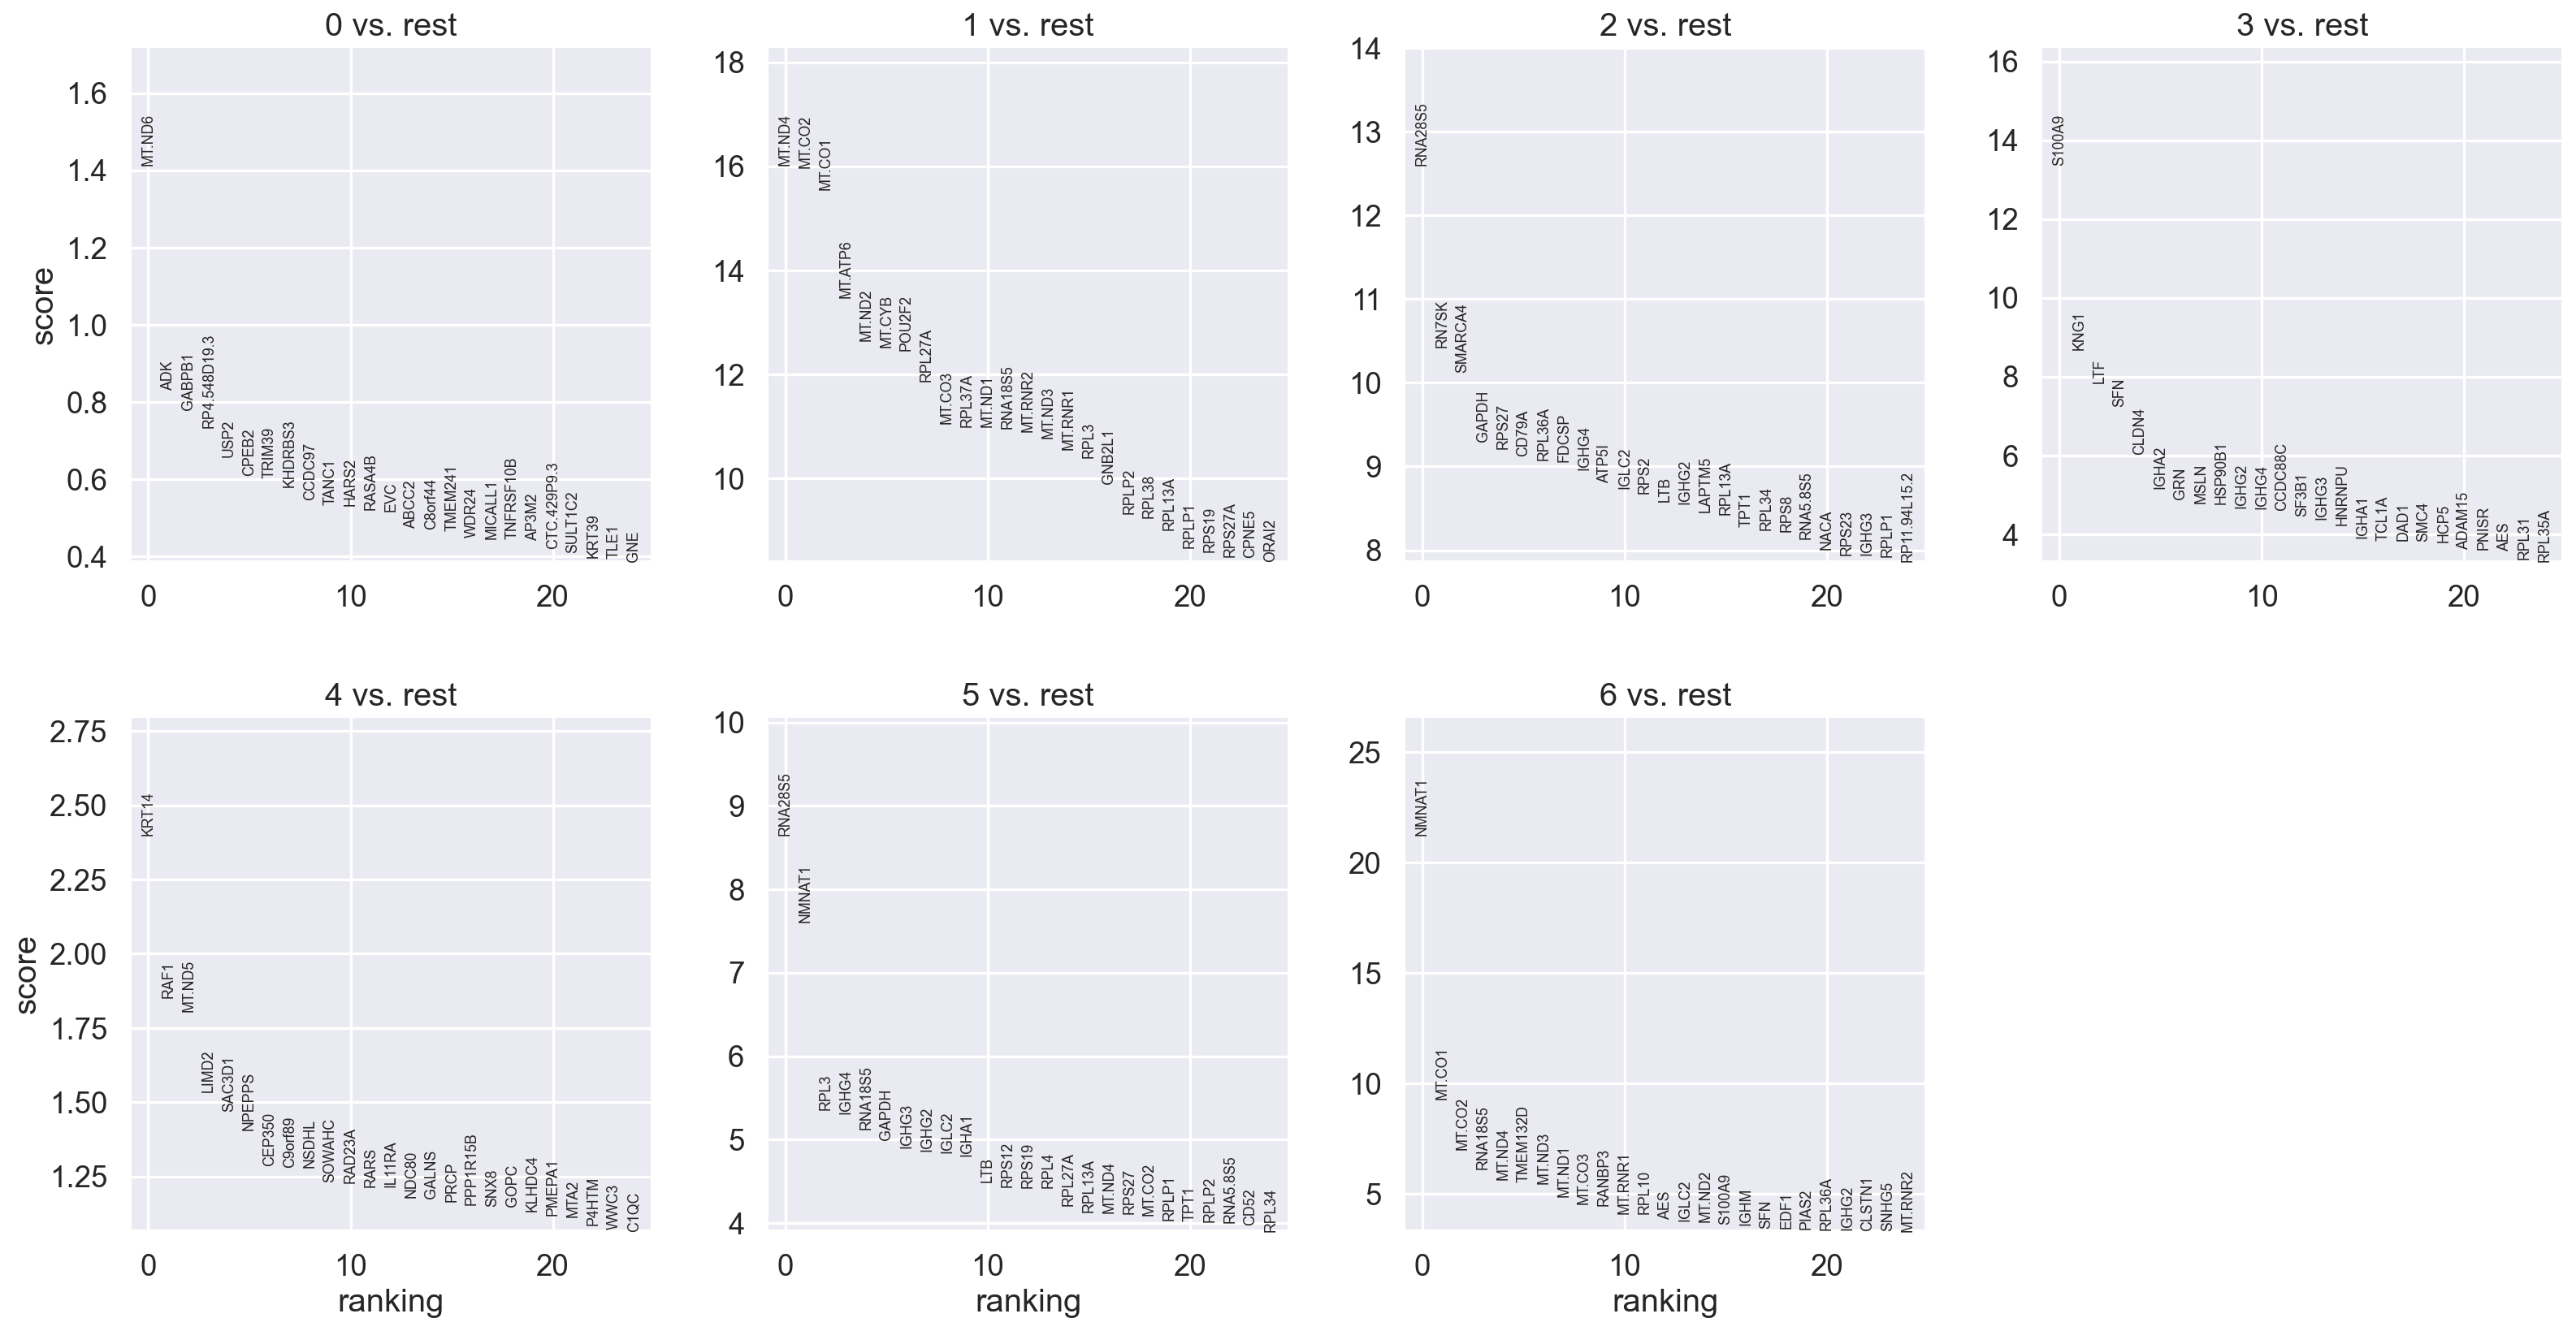

In [133]:
sc.tl.rank_genes_groups(rna_adata, groupby="cluster_eval",
                        method="wilcoxon", key_added="bayes_wilcoxon")

sc.pl.rank_genes_groups(rna_adata, n_genes=25, sharey=False,
                        key="bayes_wilcoxon")


In [135]:
rna_adata.obs["bayes_cluster"] = rna_adata.obs["bayes_cluster"].astype("category")


In [136]:
sc.tl.rank_genes_groups(
    rna_adata,
    groupby="bayes_cluster",
    method="wilcoxon",
    key_added="rna_DE"
)


In [137]:
print(rna_adata.uns["rna_DE"].keys())


dict_keys(['params', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges'])


In [139]:
#Extract all DE results
rna_markers = sc.get.rank_genes_groups_df(
    rna_adata,
    group=None,        
    key="rna_DE"
)

# Get top 10 per cluster
rna_top = rna_markers.groupby("group").head(10)
rna_top

/var/folders/ld/y2d7q4js6lz_kjlfn5cjgsq00000gp/T/ipykernel_32634/1394452503.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rna_top = rna_markers.groupby("group").head(10)


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,1,NMNAT1,15.292982,46.697475,8.515907e-53,1.703181e-49
1,1,RNA18S5,11.891325,43.060215,1.313063e-32,1.313063e-29
2,1,MT.CO1,10.830278,4.931621,2.474011e-27,1.649341e-24
3,1,MT.CO2,8.041170,3.771519,8.898486e-16,4.449243e-13
4,1,MT.ND4,6.576896,3.833289,4.803715e-11,1.921486e-08
...,...,...,...,...,...,...
14005,8,MT.ND2,9.359009,1.657265,8.048822e-21,2.682941e-18
14006,8,MT.CYB,9.088063,2.217164,1.008191e-19,2.880545e-17
14007,8,MT.ND3,8.254354,1.842878,1.527268e-16,3.818169e-14
14008,8,MT.ND1,8.079509,1.613467,6.502826e-16,1.445072e-13


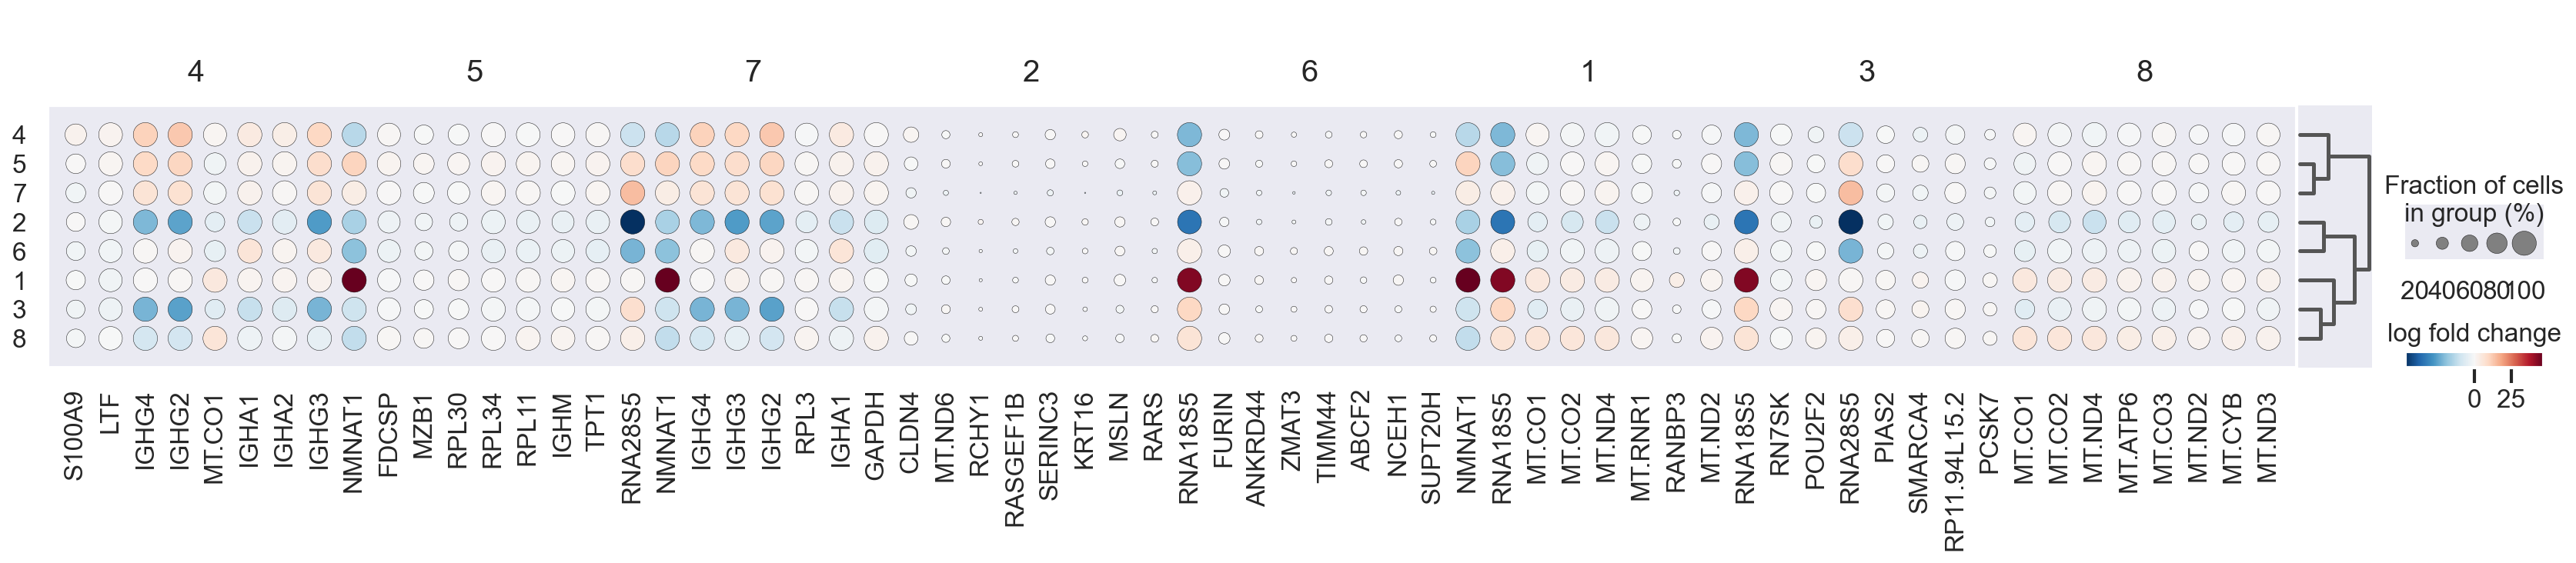

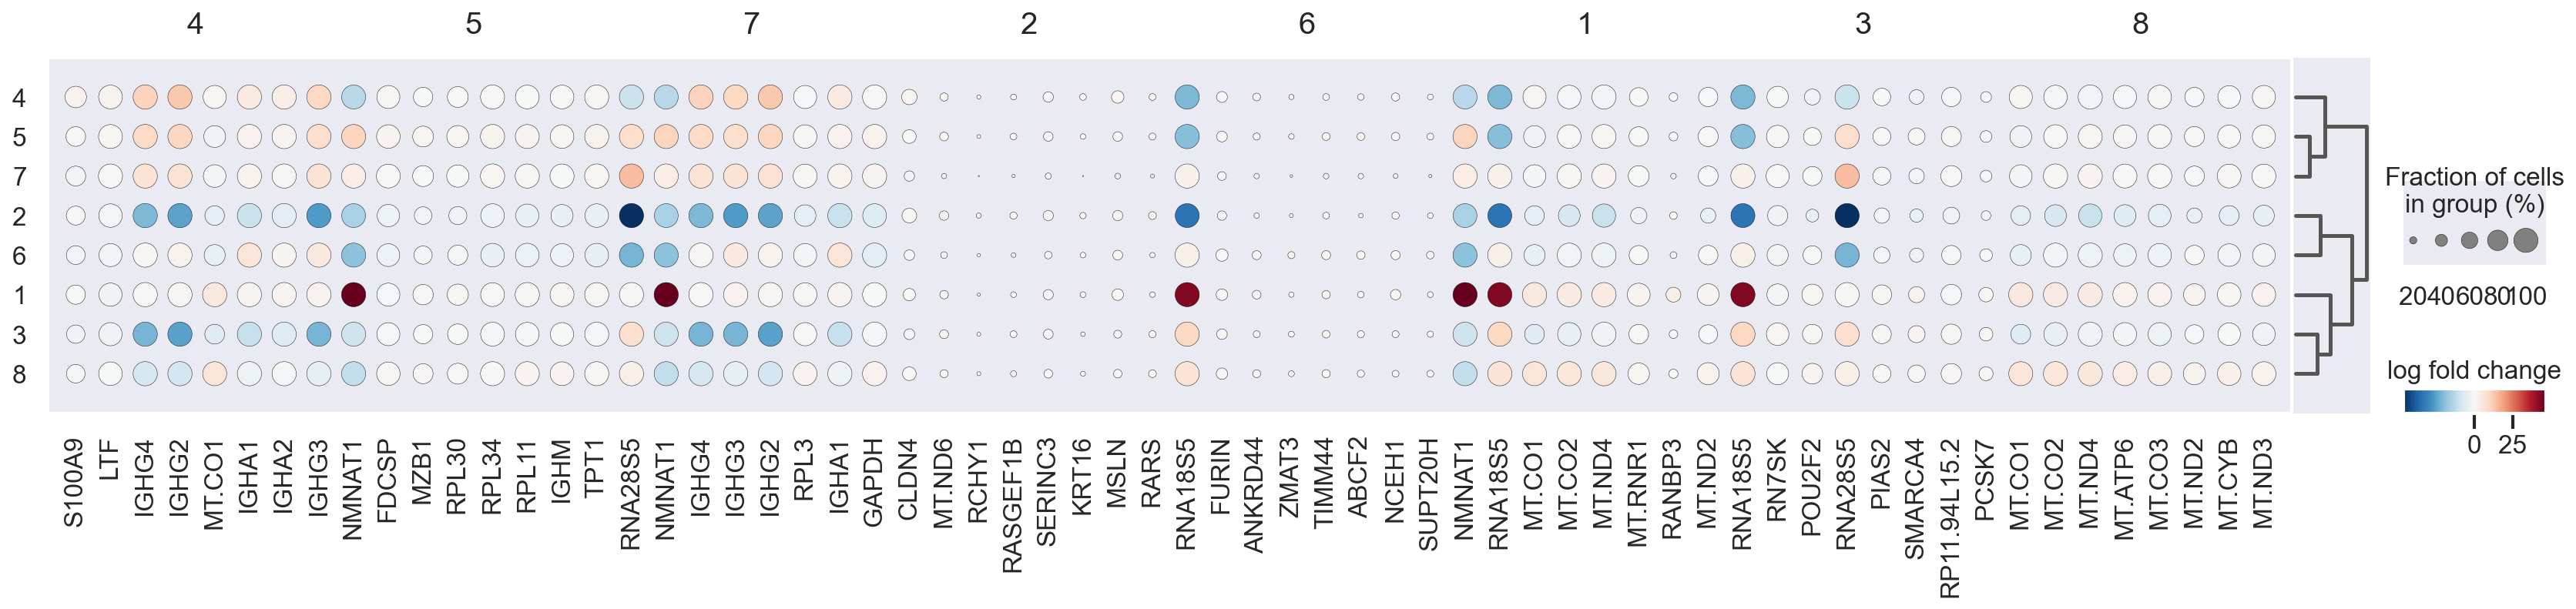

In [143]:
sc.tl.dendrogram(rna_adata, groupby="bayes_cluster")

rna_dotplot = sc.pl.rank_genes_groups_dotplot(
    rna_adata,
    n_genes=8,
    values_to_plot="logfoldchanges",
    key="rna_DE",               
    groupby="bayes_cluster",    
    cmap="RdBu_r",
    vcenter=0,
    dendrogram=True,
    return_fig=True,
    show=False                  
)

rna_dotplot.show()


rna_dotplot.savefig(
    "results/BayesSpace_RNan_DE_dotplot.png",
    dpi=300,
    bbox_inches="tight"
)


# DE for Protein Data (NA since BayesSpace doesn't use protein)